# Dataset EDA — Reuters-21578, BBC News & AG News
**Students as Researchers 2026 — Objective O3**

EDA for three benchmark datasets covering:
document count, shape/describe, first 5 rows, sentence count distribution,
document length distribution, class/topic distribution, vocabulary statistics,
short/medium/long document examples, and proportion too short for sentence-level embedding.

## Step 0 — Install

In [ ]:
!pip install -q datasets nltk scikit-learn pandas matplotlib seaborn kaggle
# Note: AG News is loaded via HuggingFace datasets (fancyzhx/ag_news) — no Kaggle auth needed

## Step 1 — Imports and helpers

In [ ]:
import nltk
nltk.download('reuters',  quiet=True)
nltk.download('punkt',    quiet=True)
nltk.download('punkt_tab',quiet=True)
warnings_shown = False

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re, warnings
warnings.filterwarnings('ignore')

from nltk.corpus import reuters
from nltk.tokenize import sent_tokenize
from datasets import load_dataset, concatenate_datasets

# ── Pandas display options ──────────────────────────────────────────────────
pd.set_option('display.max_colwidth',  120)
pd.set_option('display.max_columns',   20)
pd.set_option('display.width',         140)

# ── Plot theme ──────────────────────────────────────────────────────────────
sns.set_style('darkgrid')
plt.rcParams.update({
    'figure.facecolor':'#0d1117', 'axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d',   'text.color':'#c9d1d9',
    'axes.labelcolor':'#c9d1d9',  'xtick.color':'#8b949e',
    'ytick.color':'#8b949e',      'grid.color':'#21262d',
    'font.family':'DejaVu Sans',  'figure.dpi':110,
})
C = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657', '#79c0ff']

# ── Text helpers ────────────────────────────────────────────────────────────
def clean(text):
    return re.sub(r'\s+', ' ', str(text)).strip()

def word_count(text):
    return len(text.split())

def sent_count(text):
    try:    return max(1, len(sent_tokenize(str(text))))
    except: return 1

def vocab_stats(texts, cap=60000):
    tokens = []
    for t in texts[:cap]:
        tokens.extend(re.findall(r'\b[a-z]+\b', t.lower()))
    freq  = Counter(tokens)
    hapax = sum(1 for v in freq.values() if v == 1)
    return dict(vocab=len(freq), tokens=len(tokens),
                ttr=round(len(freq)/max(len(tokens),1), 4),
                hapax=hapax,
                hapax_pct=round(hapax/max(len(freq),1)*100, 1))

def short_pct(wcs, scs, min_w=50, min_s=3):
    mask = (np.array(wcs) < min_w) | (np.array(scs) < min_s)
    return round(mask.mean()*100, 1)

# ── DataFrame builder ───────────────────────────────────────────────────────
def build_df(texts, labels, multilabel=False):
    if multilabel:
        primary  = [ls[0] if ls else 'unlabeled' for ls in labels]
        all_labs = ['|'.join(ls) if ls else 'unlabeled' for ls in labels]
    else:
        primary  = list(labels)
        all_labs = list(labels)
    wcs = [word_count(t) for t in texts]
    scs = [sent_count(t) for t in texts]
    return pd.DataFrame({
        'text':       texts,
        'label':      primary,
        'all_labels': all_labs,
        'word_count': wcs,
        'sent_count': scs,
        'char_count': [len(t) for t in texts],
    })

# ── Dataset overview: shape + describe + category counts ────────────────────
def dataset_overview(df, name):
    SEP = '='*65
    print(f'\n{SEP}')
    print(f'  {name}')
    print(SEP)
    print(f'\n  Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'  Columns: {list(df.columns)}')
    print(f'\n  --- describe() ---')
    print(df[['word_count','sent_count','char_count']].describe().round(1).to_string())
    cats = df['label'].value_counts()
    print(f'\n  --- Categories ({len(cats)} total) ---')
    print(cats.to_string())

# ── EDA plots + printed summary ─────────────────────────────────────────────
# Covers: doc length distribution, sentence count distribution,
#         class/topic distribution, vocabulary stats,
#         short/medium/long examples, proportion too short
def eda_plots(name, df, color='#58a6ff', multilabel=False):
    wcs = df['word_count'].tolist()
    scs = df['sent_count'].tolist()
    sp  = short_pct(wcs, scs)
    vs  = vocab_stats(df['text'].tolist())

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), facecolor='#0d1117')
    fig.suptitle(f'{name} — EDA plots', fontsize=13, color='#e6edf3', fontweight='bold')

    # ── Document length distribution ────────────────────────────────────────
    ax = axes[0]
    clip99 = int(np.percentile(wcs, 99))
    ax.hist(np.clip(wcs, 0, clip99), bins=50, color=color, alpha=0.80, ec='none')
    ax.axvline(np.median(wcs), color='#ff7b72', lw=1.8, ls='--',
               label=f'median={int(np.median(wcs))}w')
    ax.axvline(50, color='#d29922', lw=1.2, ls=':', label='50-word floor')
    ax.set_title('Document length distribution (words)', color='#e6edf3', fontsize=10)
    ax.set_xlabel('words'); ax.set_ylabel('count'); ax.legend(fontsize=8)

    # ── Sentence count distribution ─────────────────────────────────────────
    ax = axes[1]
    clip_sc = int(np.percentile(scs, 99))
    ax.hist(np.clip(scs, 0, clip_sc), bins=40, color=color, alpha=0.80, ec='none')
    ax.axvline(np.median(scs), color='#ff7b72', lw=1.8, ls='--',
               label=f'median={int(np.median(scs))}s')
    ax.axvline(3, color='#d29922', lw=1.2, ls=':', label='3-sent floor')
    ax.set_title('Sentence count distribution', color='#e6edf3', fontsize=10)
    ax.set_xlabel('sentences'); ax.set_ylabel('count'); ax.legend(fontsize=8)

    # ── Class / topic distribution ──────────────────────────────────────────
    ax = axes[2]
    flat = ([l for doc_labs in df['all_labels'].str.split('|') for l in doc_labs if l]
            if multilabel else df['label'].tolist())
    top  = Counter(flat).most_common(25)
    lnames, lvals = zip(*top)
    ax.barh(list(reversed(lnames)), list(reversed(lvals)), color=color, alpha=0.80)
    ax.set_title('Class / topic distribution (top 25)', color='#e6edf3', fontsize=10)
    ax.set_xlabel('document count')

    plt.tight_layout(rect=[0,0,1,0.94]); plt.show()

    # ── Printed EDA summary ─────────────────────────────────────────────────
    BAR = '─'*68
    print(f'\n{BAR}')
    print(f'  EDA Summary — {name}')
    print(BAR)
    print(f'  Document count         : {len(df):,}')
    print(f'  Words  — mean={np.mean(wcs):.0f}  median={np.median(wcs):.0f}  '
          f'min={min(wcs)}  max={max(wcs)}  std={np.std(wcs):.0f}')
    print(f'  Sentences — mean={np.mean(scs):.1f}  median={np.median(scs):.0f}  '
          f'min={min(scs)}  max={max(scs)}')
    print(f'  Chars  — mean={df["char_count"].mean():.0f}  '
          f'median={df["char_count"].median():.0f}  max={df["char_count"].max()}')
    print(f'  Vocabulary             : {vs["vocab"]:,} types  |  Tokens: {vs["tokens"]:,}')
    print(f'  Type-Token Ratio       : {vs["ttr"]}  '
          f'|  Hapax legomena: {vs["hapax"]:,} ({vs["hapax_pct"]}%)')
    print(f'  Too short (<50w or <3s): {sp}% of corpus')

    # ── Short / medium / long document examples ─────────────────────────────
    idx_s = df['word_count'].argsort().values
    n = len(idx_s)
    print(f'\n  Document examples by length percentile:')
    for lbl, i in [('SHORT  (p10)', idx_s[n//10]),
                   ('MEDIUM (p50)', idx_s[n//2]),
                   ('LONG   (p90)', idx_s[int(n*0.9)])]:
        print(f'\n  [{lbl}]  {df.iloc[i]["word_count"]}w')
        print(f'  {df.iloc[i]["text"][:300].strip()}...')
    print(f'\n{BAR}')
    return wcs, scs

print('✅  All helpers loaded.')


✅  All helpers loaded.


---
## Dataset 1 — Reuters-21578

**Source:** NLTK `reuters` corpus (UCI original Reuters-21578 collection, ModApte split)
**Why relevant:** Only dataset here with genuine multi-label ground truth — 15.1% of documents carry more than one topic label. Directly supports evaluation of soft/probabilistic mixture model outputs.
**Reference:** Lewis, D. (1997). Reuters-21578 Text Categorization Collection. UCI MLR.

In [ ]:
# ── Load via NLTK ──────────────────────────────────────────────────────────
file_ids   = reuters.fileids()
reu_texts  = [clean(reuters.raw(fid)) for fid in file_ids]
reu_labels = [reuters.categories(fid) for fid in file_ids]  # list of lists — multi-label

# ── Document count ──────────────────────────────────────────────────────────
print(f'Total documents : {len(reu_texts):,}')
print(f'Unique topics   : {len(set(l for ls in reu_labels for l in ls))}')

# ── Multi-label / class distribution counts ─────────────────────────────────
no_topic  = sum(1 for labs in reu_labels if len(labs) == 0)
multi     = sum(1 for labs in reu_labels if len(labs) > 1)
all_cats  = [l for labs in reu_labels for l in labs]
cats_lt5  = sorted([c for c in reuters.categories() if len(reuters.fileids(c)) < 5])

print(f'Docs with NO topic   : {no_topic:,} ({no_topic/len(reu_texts)*100:.1f}%)')
print(f'Docs with >1 topic   : {multi:,} ({multi/len(reu_texts)*100:.1f}%)')
print(f'Topics with <5 docs  : {len(cats_lt5)} -> {cats_lt5}')

print(f'\nTop 15 topics (class/topic distribution):')
for cat, cnt in Counter(all_cats).most_common(15):
    print(f'  {cat:<30} {cnt:>5,}  ({cnt/len(reu_texts)*100:.1f}%)')

Total documents : 10,788
Unique topics   : 90
Docs with NO topic   : 0 (0.0%)
Docs with >1 topic   : 1,628 (15.1%)
Topics with <5 docs  : 14 -> ['castor-oil', 'copra-cake', 'cotton-oil', 'cpu', 'dfl', 'groundnut-oil', 'lin-oil', 'nkr', 'nzdlr', 'palladium', 'palmkernel', 'rand', 'rye', 'sun-meal']

Top 15 topics (class/topic distribution):
  earn                           3,964  (36.7%)
  acq                            2,369  (22.0%)
  money-fx                         717  (6.6%)
  grain                            582  (5.4%)
  crude                            578  (5.4%)
  trade                            485  (4.5%)
  interest                         478  (4.4%)
  ship                             286  (2.7%)
  wheat                            283  (2.6%)
  corn                             237  (2.2%)
  dlr                              175  (1.6%)
  money-supply                     174  (1.6%)
  oilseed                          171  (1.6%)
  sugar                            162  (1.5%

In [ ]:
# ── Build DataFrame ────────────────────────────────────────────────────────
reu_df = build_df(reu_texts, reu_labels, multilabel=True)

# ── Shape & columns ─────────────────────────────────────────────────────────
print(f'Shape  : {reu_df.shape[0]:,} rows x {reu_df.shape[1]} columns')
print(f'Columns: {list(reu_df.columns)}')

# ── First 5 rows (all columns) ──────────────────────────────────────────────
print('\nFirst 5 rows:')
reu_df.head(5)


Shape  : 10,788 rows x 6 columns
Columns: ['text', 'label', 'all_labels', 'word_count', 'sent_count', 'char_count']

First 5 rows:


,label,all_labels,word_count,sent_count,char_count
0,trade,trade,713,31,4416
1,grain,grain,108,5,625
2,crude,crude|nat-gas,173,6,1079
3,corn,corn|grain|rice|rubber|sugar|tin|trade,148,7,899
4,palm-oil,palm-oil|veg-oil,158,6,982


In [ ]:
dataset_overview(reu_df, 'Reuters-21578')


  Reuters-21578

  Shape  : 10,788 rows x 6 columns
  Columns: ['text', 'label', 'all_labels', 'word_count', 'sent_count', 'char_count']

  --- describe() ---
       word_count  sent_count  char_count
count     10788.0     10788.0     10788.0
mean        127.8         5.0       765.1
std         136.1         5.7       828.1
min           2.0         1.0        23.0
25%          44.0         1.0       247.0
50%          84.0         3.0       496.0
75%         158.0         6.0       962.0
max        1672.0        62.0      9903.0

  --- Categories (79 total) ---
label
earn               3926
acq                2369
crude               552
interest            453
money-fx            362
trade               329
grain               295
corn                205
dlr                 169
money-supply        154
ship                151
coffee              126
sugar               123
gold                109
bop                 105
gnp                 101
cpi                  91
cocoa          

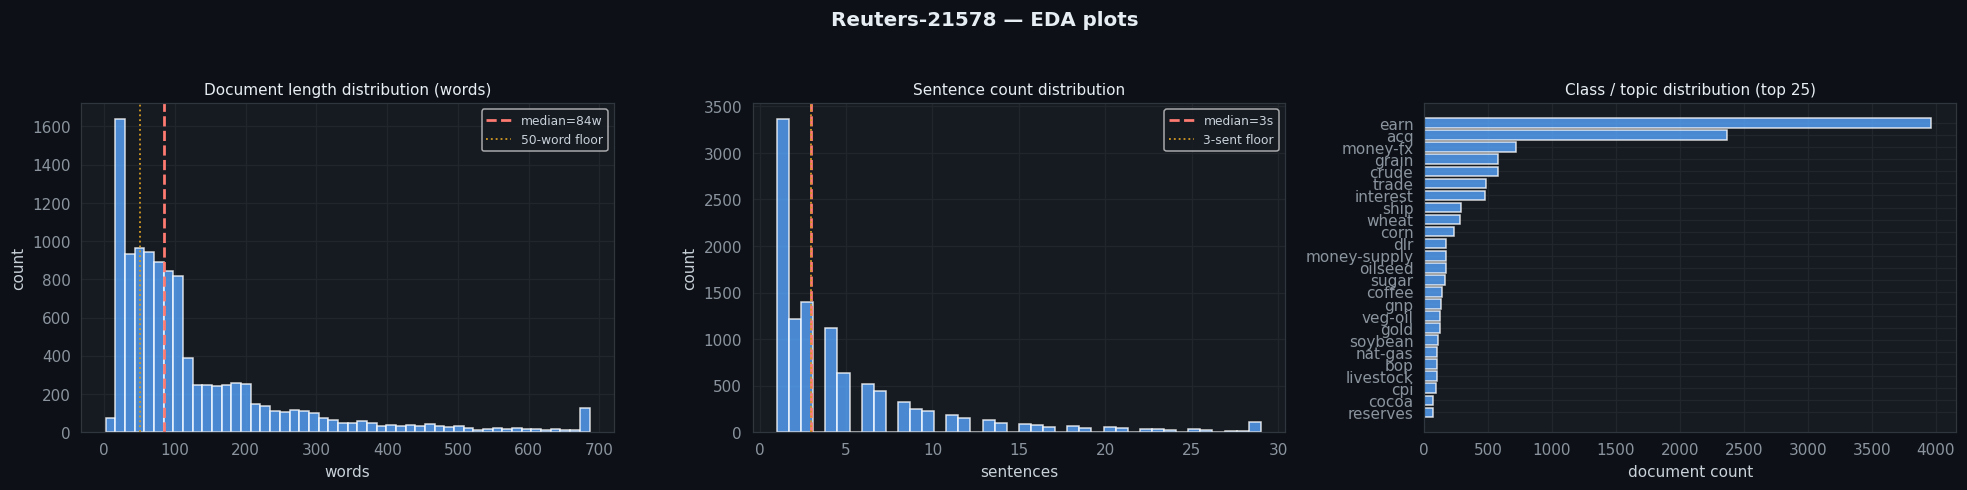


────────────────────────────────────────────────────────────────────
  EDA Summary — Reuters-21578
────────────────────────────────────────────────────────────────────
  Document count         : 10,788
  Words  — mean=128  median=84  min=2  max=1672  std=136
  Sentences — mean=5.0  median=3  min=1  max=62
  Chars  — mean=765  median=496  max=9903
  Vocabulary             : 29,172 types  |  Tokens: 1,327,140
  Type-Token Ratio       : 0.022  |  Hapax legomena: 10,549 (36.2%)
  Too short (<50w or <3s): 43.5% of corpus

  Document examples by length percentile:

  [SHORT  (p10)]  24w
  &lt;BATON BROADCASTING INC> SIX MTHS FEB 28 NET Shr 33 cts vs 31 cts Net 9,219,017 vs 8,515,539 Revs 112.0 mln vs 95.4 mln...

  [MEDIUM (p50)]  84w
  UK MONEY MARKET GIVEN LATE HELP OF 185 MLN STG The Bank of England said it gave the money market late, unspecified assistance of around 185 mln stg. This takes the total liquidity injected into the system by the bank today to 1.026 billion stg compared with 

In [ ]:
reu_wc, reu_sc = eda_plots('Reuters-21578', reu_df, color=C[0], multilabel=True)

---
## Dataset 5 — BBC News

**Source:** HuggingFace `SetFit/bbc-news` (raw text)
**Why relevant:** 2,225 full BBC articles across 5 well-defined non-overlapping categories. 0% of documents too short. Best corpus for boundary-detection validation before testing on complex overlapping datasets.
**Reference:** Greene & Cunningham (2006). Practical solutions to the problem of diagonal dominance in kernel document clustering. ICML.

In [ ]:
# ── Load BOTH splits using concatenate_datasets ─────────────────────────────
# FIX: split='train+test' string syntax is unreliable for this dataset.
# Load train and test separately then combine — guarantees all 2,225 docs.
bbc_train = load_dataset('SetFit/bbc-news', split='train')
bbc_test  = load_dataset('SetFit/bbc-news', split='test')

# FIX: test split may use int labels instead of string labels.
# Standardise both splits before combining.
label_map = {0:'business', 1:'entertainment', 2:'politics', 3:'sport', 4:'tech'}

def get_label_text(row):
    if 'label_text' in row and row['label_text']:
        return str(row['label_text'])
    if 'label' in row and isinstance(row['label'], int):
        return label_map.get(row['label'], 'unknown')
    return str(row.get('label', 'unknown'))

bbc_texts  = [clean(r['text']) for r in bbc_train] + [clean(r['text']) for r in bbc_test]
bbc_labels = [get_label_text(r) for r in bbc_train] + [get_label_text(r) for r in bbc_test]

# ── Document count ──────────────────────────────────────────────────────────
print(f'Total documents : {len(bbc_texts):,} (train={len(bbc_train)}, test={len(bbc_test)})')
print(f'Categories      : {sorted(set(bbc_labels))}')

# ── Class / topic distribution counts ───────────────────────────────────────
bbc_cat_cnts = Counter(bbc_labels)
print(f'\nClass distribution:')
for cat, cnt in sorted(bbc_cat_cnts.items(), key=lambda x: -x[1]):
    print(f'  {cat:<20} {cnt:>5,}  ({cnt/len(bbc_texts)*100:.1f}%)')
print(f'\nBalance ratio (largest/smallest): '
      f'{max(bbc_cat_cnts.values())/min(bbc_cat_cnts.values()):.2f}:1')

README.md:   0%|          | 0.00/880 [00:00<?, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1225 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Total documents : 2,225 (train=1225, test=1000)
Categories      : ['business', 'entertainment', 'politics', 'sport', 'tech']

Class distribution:
  sport                  511  (23.0%)
  business               510  (22.9%)
  politics               417  (18.7%)
  tech                   401  (18.0%)
  entertainment          386  (17.3%)

Balance ratio (largest/smallest): 1.32:1


In [ ]:
# ── Build DataFrame ────────────────────────────────────────────────────────
bbc_df = build_df(bbc_texts, bbc_labels, multilabel=False)

# ── Shape & columns ─────────────────────────────────────────────────────────
print(f'Shape  : {bbc_df.shape[0]:,} rows x {bbc_df.shape[1]} columns')
print(f'Columns: {list(bbc_df.columns)}')

# ── First 5 rows (all columns) ──────────────────────────────────────────────
print('\nFirst 5 rows:')
bbc_df.head(5)


Shape  : 2,225 rows x 6 columns
Columns: ['text', 'label', 'all_labels', 'word_count', 'sent_count', 'char_count']

First 5 rows:


,label,word_count,sent_count,char_count
0,sport,248,10,1401
1,business,238,11,1366
2,entertainment,235,12,1306
3,business,391,15,2329
4,tech,630,30,3510


In [ ]:
dataset_overview(bbc_df, 'BBC News')


  BBC News

  Shape  : 2,225 rows x 6 columns
  Columns: ['text', 'label', 'all_labels', 'word_count', 'sent_count', 'char_count']

  --- describe() ---
       word_count  sent_count  char_count
count      2225.0      2225.0      2225.0
mean        390.3        17.8      2233.5
std         241.8        11.7      1346.0
min          90.0         4.0       497.0
25%         250.0        11.0      1427.0
50%         337.0        15.0      1939.0
75%         479.0        22.0      2764.0
max        4492.0       227.0     25216.0

  --- Categories (5 total) ---
label
sport            511
business         510
politics         417
tech             401
entertainment    386


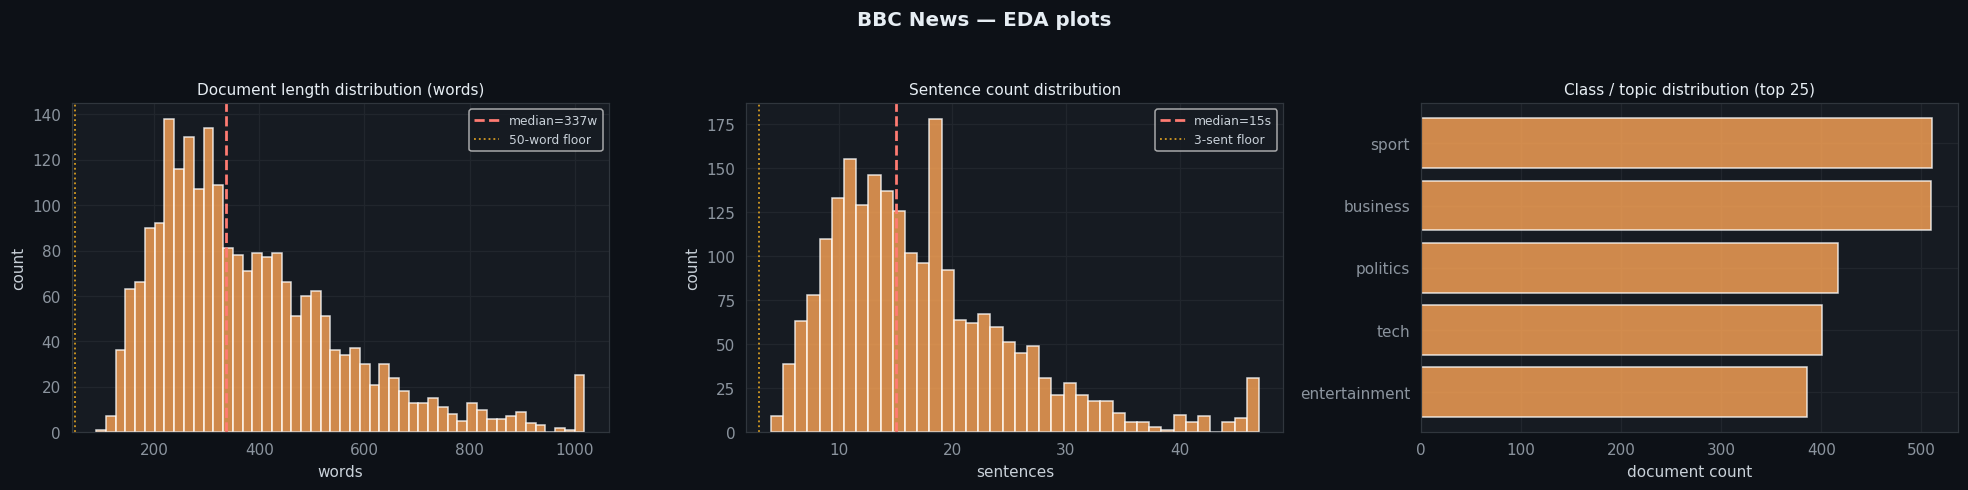


────────────────────────────────────────────────────────────────────
  EDA Summary — BBC News
────────────────────────────────────────────────────────────────────
  Document count         : 2,225
  Words  — mean=390  median=337  min=90  max=4492  std=242
  Sentences — mean=17.8  median=15  min=4  max=227
  Chars  — mean=2233  median=1939  max=25216
  Vocabulary             : 27,877 types  |  Tokens: 855,598
  Type-Token Ratio       : 0.0326  |  Hapax legomena: 9,263 (33.2%)
  Too short (<50w or <3s): 0.0% of corpus

  Document examples by length percentile:

  [SHORT  (p10)]  194w
  argentina venezuela in oil deal argentina and venezuela have extended a food-for-oil deal which helped the former to overcome a severe energy crisis last year. argentine president nestor kirchner and venezuelan president hugo chavez signed the deal in buenos aires on tuesday. last april argentina si...

  [MEDIUM (p50)]  337w
  wales stars need a rest - ruddock wales coach mike ruddock has defended his dec

In [ ]:
bbc_wc, bbc_sc = eda_plots('BBC News', bbc_df, color=C[4], multilabel=False)

---
## Dataset 3 — AG News

**Source:** HuggingFace `fancyzhx/ag_news` (same data as Kaggle, no auth required)
**Original:** https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset
**Why relevant:** Large-scale single-label dataset (120K train + 7,600 test). 4 balanced categories: World, Sports, Business, Sci/Tech (30,000 docs each in train). Used as a pipeline scale test — if SBERT embedding and GMM clustering run correctly on 120K short articles, the pipeline can handle larger workloads. Single-label only so used for hard clustering baseline comparison (K-Means vs HDBSCAN vs GMM) rather than soft-clustering validation.
**Reference:** Zhang, X., Zhao, J. & LeCun, Y. (2015). Character-level Convolutional Networks for Text Classification. NeurIPS 2015.

In [ ]:
# ── Load via HuggingFace (fancyzhx/ag_news) ────────────────────────────────
# Same underlying data as the Kaggle version — no Kaggle API key needed.
# Each row has: text (title + description concatenated), label (int 0-3)
# Label map: 0=World, 1=Sports, 2=Business, 3=Sci/Tech
ag_label_map = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

ag_train = load_dataset('fancyzhx/ag_news', split='train')
ag_test  = load_dataset('fancyzhx/ag_news', split='test')

ag_texts  = [clean(r['text']) for r in ag_train] + [clean(r['text']) for r in ag_test]
ag_labels = [ag_label_map[r['label']] for r in ag_train] + \
            [ag_label_map[r['label']] for r in ag_test]

# ── Document count ──────────────────────────────────────────────────────────
print(f'Total documents : {len(ag_texts):,} (train={len(ag_train):,}, test={len(ag_test):,})')
print(f'Categories      : {sorted(set(ag_labels))}')

# ── Class distribution counts ────────────────────────────────────────────────
ag_cat_cnts = Counter(ag_labels)
print(f'\nClass distribution:')
for cat, cnt in sorted(ag_cat_cnts.items(), key=lambda x: -x[1]):
    print(f'  {cat:<15} {cnt:>7,}  ({cnt/len(ag_texts)*100:.1f}%)')
print(f'\nBalance ratio (largest/smallest): '
      f'{max(ag_cat_cnts.values())/min(ag_cat_cnts.values()):.2f}:1')

In [ ]:
# ── Build DataFrame ────────────────────────────────────────────────────────
ag_df = build_df(ag_texts, ag_labels, multilabel=False)

# ── Shape & columns ─────────────────────────────────────────────────────────
print(f'Shape  : {ag_df.shape[0]:,} rows x {ag_df.shape[1]} columns')
print(f'Columns: {list(ag_df.columns)}')

# ── First 5 rows (all columns) ──────────────────────────────────────────────
print('\nFirst 5 rows:')
ag_df.head(5)

In [ ]:
dataset_overview(ag_df, 'AG News')

In [ ]:
# Note: vocab_stats caps at 60,000 docs for speed (AG News has 127,600 docs).
# The cap is already built into the vocab_stats() helper — no change needed.
ag_wc, ag_sc = eda_plots('AG News', ag_df, color=C[2], multilabel=False)